## Week 2: Shewhart Charts for Variables
### Dr. Austin Brown
### School of Data Science & Analytics

In [ ]:
## Clone your forked repository to Colab ##

## Specify your user name (change to your own):

#user_name <- "abrown9008"

## Set web address to forked repository (change to your own):

#repo_address <- paste0("www.github.com/", user_name, "/STAT-7110-Quality-Control")

## Check to see if repo is already cloned to Colab, and if not, clone repo:

#if(!dir.exists("STAT-7110-Quality-Control")) {
#  system(paste0("git clone ", repo_address))
#} else {
#  print("Repository already cloned to Colab.")
#}

## Set working drive to today's lecture:

#setwd("Slides//Week-2-Shewhart-Charts-for-Variables")

### Table of Contents
1. [Introduction to Control Charts](#introduction-to-control-charts)
2. [The Shewhart $\bar{X}$ and R Control Charts](#the-shewhart-x-and-r-control-charts)
3. [Process Capability](#process-capability)

---

## Introduction to Control Charts

As introduced last week, a control chart is a graphical monitoring tool rooted in statistical theory. Recall that all control charts share three key elements:

| Element | Description |
|---|---|
| **Plotting Statistic** | A summary statistic derived from random samples of the monitored process |
| **Target Value** | The in-control value the process ideally adheres to |
| **Control Limits** | Thresholds analogous to critical values in hypothesis testing |

A well-designed control chart balances two competing goals:

1. **Sensitivity** — if the process has shifted away from target, the chart signals in as few samples as possible
2. **Specificity** — if the process is in-control, false alarms are infrequent

---

### A Brief History

The original control chart, and still the most well-known, is the **Shewhart $\bar{X}$-chart**, developed by **Walter Shewhart** during his work at Bell Labs in the 1920s. Shewhart was a friend and mentor to **W. Edwards Deming**, widely regarded as the godfather of modern quality management.

---

## The Shewhart $\bar{X}$ and R Control Charts

When monitoring a continuous variable, we care about two things:

- **Process location** — is the mean staying where it should be?
- **Process variability** — is the spread of the process staying stable?

This is why the $\bar{X}$ and R charts are almost always used together:

| Chart | Monitors | Plotting Statistic |
|---|---|---|
| $\bar{X}$-chart | Process mean | Sample mean $\bar{x}_t$ |
| R-chart | Process variability | Sample range $R_t$ |

---

### Case 1: Known $\mu_0$ and $\sigma_0$

Assume the monitored process follows a Normal distribution with known in-control mean $\mu_0$ and standard deviation $\sigma_0$. At each time point $t = 1, 2, \ldots$ we collect a random sample of size $n$ and compute:

$$\bar{x}_t = \frac{1}{n}\sum_{i=1}^{n}x_i$$

By the **Central Limit Theorem**, as long as $X$ has finite variance:

$$\bar{x} \stackrel{\cdot}{\sim} N\!\left(\mu_0,\, \frac{\sigma_0}{\sqrt{n}}\right)$$

This gives us the $\bar{X}$-chart control limits:

$$UCL = \mu_0 + L\frac{\sigma_0}{\sqrt{n}}, \qquad CL = \mu_0, \qquad LCL = \mu_0 - L\frac{\sigma_0}{\sqrt{n}}$$

---

### Choosing $L$: The Role of $\alpha$

$L$ is chosen the same way we choose critical values in a two-sided $Z$-test. In both instances, we specify an acceptable $\alpha$ level, where $\alpha$ is the probability of a **false alarm** at any given time point.

- **$\alpha$ too large** → narrow control limits → too many false alarms
- **$\alpha$ too small** → wide control limits → real shifts go undetected

In practice, control charts are generally operated at $\alpha = 0.0027$, which yields $L = 3.00$. This is the origin of the term **Six Sigma**. A process running at $\pm 3\sigma$ from its mean produces very few nonconforming units.

---

### Case 2: Unknown $\mu_0$ and $\sigma_0$ (The Typical Case)

In practice, the true in-control parameters are rarely known and must be **estimated from historical data**. This is the work of **Phase I**.

Phase I is part of the **Analyze** and **Improve** components of the DMAIC process.

In Phase I, we collect $m$ historical samples of size $n$ and estimate:

$$\hat{\mu}_0 = \bar{\bar{x}} = \frac{1}{m}\sum_{i=1}^{m}\bar{x}_i$$

$$\hat{\sigma}_0 \approx \frac{\bar{R}}{d_2}, \qquad \text{where } \bar{R} = \frac{1}{m}\sum_{i=1}^{m}R_i$$

The estimated control limits for the $\bar{X}$-chart become:

$$UCL = \bar{\bar{x}} + \frac{3}{d_2\sqrt{n}}\bar{R}, \qquad CL = \bar{\bar{x}}, \qquad LCL = \bar{\bar{x}} - \frac{3}{d_2\sqrt{n}}\bar{R}$$

And for the R-chart:

$$UCL = D_4\bar{R}, \qquad CL = \bar{R}, \qquad LCL = D_3\bar{R}$$

$d_2$, $D_3$, and $D_4$ are **control chart constants** that depend only on the sample size $n$. They can be found in Table VI of the Montgomery text or at the link below:

> 📋 [Control Chart Constants Reference (MIT)](https://web.mit.edu/2.810/www/files/readings/ControlChartConstantsAndFormulae.pdf)

---

### How Large Should $m$ and $n$ Be?

| Parameter | Recommendation |
|---|---|
| $n$ (sample size) | 4 or 5 is standard and perfectly adequate |
| $m$ (number of samples) | Your text suggests 20–30, but research, and your instructor, recommends closer to **100**; some studies suggest up to 500 |

The intuition: a poorly estimated $\hat{\sigma}_0$ from too few Phase I samples will produce control limits that are either too tight or too loose, undermining the entire Phase II monitoring program.

---

### Phase I: Checking That the Process Is Already In-Control

Here's a subtlety worth pausing on: **what if the process isn't in control during Phase I?** If out-of-control points contaminate our Phase I data, we're building error into the control limits from the start.

The Phase I procedure accounts for this:

1. Compute the Phase I control limits from the $m$ samples
2. Plot each $\bar{x}_i$ and $R_i$ against those limits
3. Investigate any point that plots beyond the limits for an **assignable cause**
4. If found: correct the cause, remove the point, and **recalculate the limits**
5. Repeat until all points fall within the limits → the process is in statistical control → proceed to **Phase II**

> **What if no assignable cause is found?**
> Your text offers two options: (1) drop the point anyway, or (2) retain it and treat it as a false alarm. Neither is ideal, but with a large enough $m$, a few dropped points won't meaningfully distort the estimates.
>
> If *many* points are out of control, individual investigation isn't practical. In that case, look for **patterns** in the plotted points. For instance, systematic runs above or below the centerline, oscillating patterns, trends, etc. These often point toward a process-level cause.

---

### Example: Flow Width Measurements

We'll now work through a full Phase I analysis using the data from **Table 6.1** of the Montgomery text: flow width measurements (in microns) from a hard-bake process, with $m = 25$ samples of size $n = 5$.

> ✏️ **Your turn:** Load the Excel file, compute $\bar{x}_i$ and $R_i$ for each sample, estimate $\bar{\bar{x}}$ and $\bar{R}$, and plot both the $\bar{X}$ and R charts. Are all points in control?

---

Rows: 25
Columns: 6
$ `Sample Number` <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 1…
$ `Wafer 1`       <dbl> 1.3235, 1.4314, 1.4284, 1.5028, 1.5604, 1.5955, 1.62…
$ `Wafer 2`       <dbl> 1.4128, 1.3592, 1.4871, 1.6352, 1.2735, 1.5451, 1.50…
$ `Wafer 3`       <dbl> 1.6744, 1.6075, 1.4932, 1.3841, 1.5265, 1.3574, 1.83…
$ `Wafer 4`       <dbl> 1.4573, 1.4666, 1.4324, 1.2831, 1.4363, 1.3281, 1.41…
$ `Wafer 5`       <dbl> 1.6914, 1.6109, 1.5674, 1.5507, 1.6441, 1.4198, 1.51…


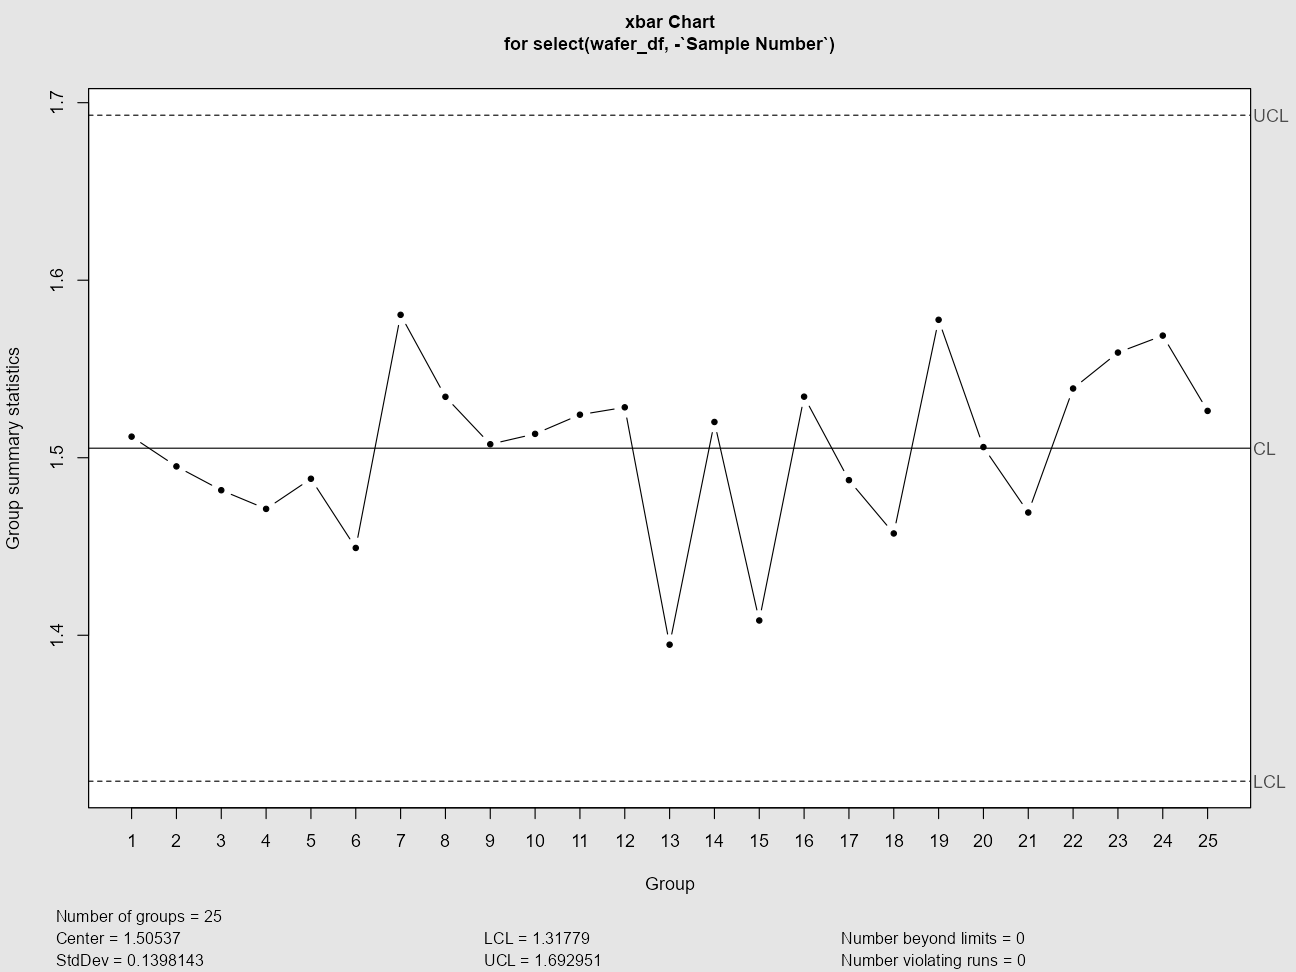

In [12]:
## Install tidyverse, readxl, and qcc packages if necessary ##

install.packages(c("tidyverse", "readxl", "qcc"))

## Load the libraries ##

library(tidyverse)
library(readxl)
library(qcc)

## Read in the Wafer Data ##

wafer_df <- read_excel("Wafer Data.xlsx")

## Data Integrity Check ##

wafer_df |>
  glimpse()

## These data are organized in "wide format" 
## where each row represents a point in time 
## rather than a unique observation.
## For the qcc package, wide data is typically
## what we need. ##

## Save and plot phase 1 xbar chart ##

phase1_xbar <- qcc(wafer_df |> select(-`Sample Number`), 
                   type = "xbar",
                   plot = TRUE)

### Interpreting the Phase I $\bar{X}$-Chart

From this chart we can read off the key Phase I estimates directly:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{\bar{x}}$) | $1.505$ |
| Std. Dev. ($\hat{\sigma}$) | $0.1398$ |
| LCL | $1.32$ |
| UCL | $1.69$ |

Note that the default estimation technique for the process standard deviation given by the `qcc` function is the one stated above. We have alternative methods for estimating process standard deviation that we'll discuss later in this class.

The chart also reports the number of points exceeding the control limits (zero in this case) and the number of **violating runs**, which are sequences of plotted points that are statistically improbable even when all points fall within the control limits.

> **What is a violating run?** Imagine 10 consecutive points all plotting above the centerline but below the UCL. Each individual point looks fine, but the pattern as a whole is highly unlikely under a stable, in-control process. Runs like this can signal a systematic shift in the process that the control limits alone wouldn't catch.

Let's now examine the Phase 1 R Chart:

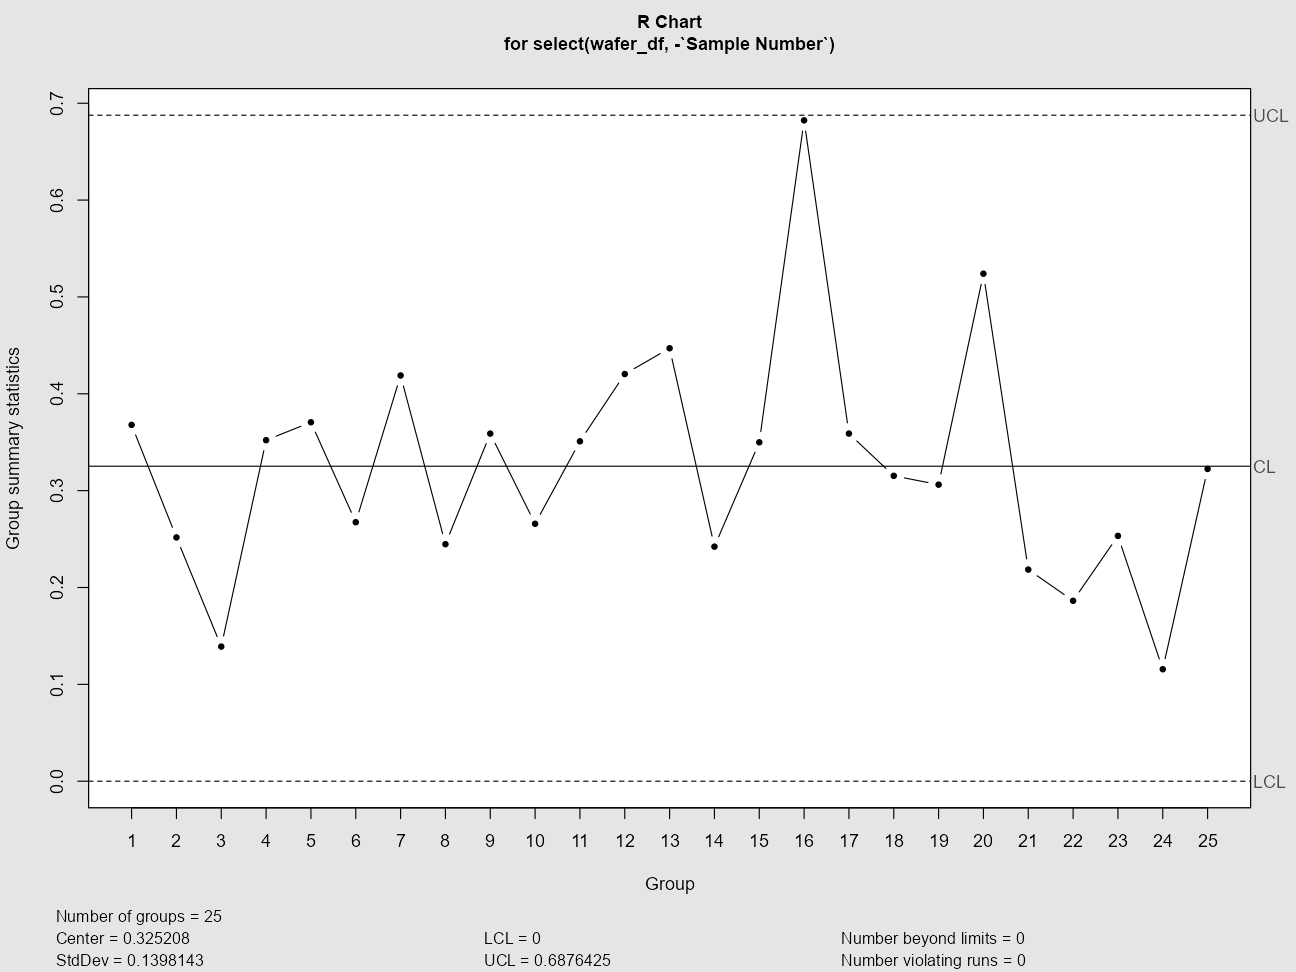

In [13]:
## Save and plot Phase 1 R Chart ##

phase1_r <- qcc(wafer_df |> select(-`Sample Number`), 
                 type = "R",
                 plot = TRUE)

### Interpreting the Phase 1 R-Chart

Similarly, we can read off Phase 1 estimates directly from this figure:

| Output | Value |
|---|---|
| Number of groups | $m = 25$ |
| Center ($\bar{R}$) | $0.3252$ |
| Std. Dev. ($\hat{\sigma}$) | $0.1398$ |
| LCL | $0$ |
| UCL | $0.6876$ |

As was the case with the $\bar{x}$-chart, we had no points beyond the limits and no violating runs.  

In sum, this would indicate to us that we have historically had an in-control, stable process where:

\begin{align*}
\hat{\mu}_0 &= \bar{\bar{x}} = 1.505 \\
\hat{\sigma}_0 &= \frac{\bar{R}}{d_2} = \frac{0.3252}{2.326} \\
&\approx 0.1398 
\end{align*}

## Process Capability

Once Phase I establishes that a process is **in statistical control**, we move to a second question as part of Phase I:

> *Is the process actually producing items that meet specifications?*

A process can be perfectly in control — behaving consistently and predictably — and still be producing nonconforming units if its natural variability is too large. This is the concept of **process capability**.

---

### Specification Limits vs. Control Limits

It's important not to confuse these two:

| | Set By | Purpose |
|---|---|---|
| **Control Limits** | The data / process | Detect when the process has changed |
| **Specification Limits (USL/LSL)** | The customer or engineer | Define what's an acceptable product |

A process is **capable** when its natural spread (typically $\hat{\mu} \pm 3\hat{\sigma}$, the **natural tolerance limits**) falls *inside* the specification limits.

---

### Visual Intuition

The plot below illustrates what we're examining in process capability:

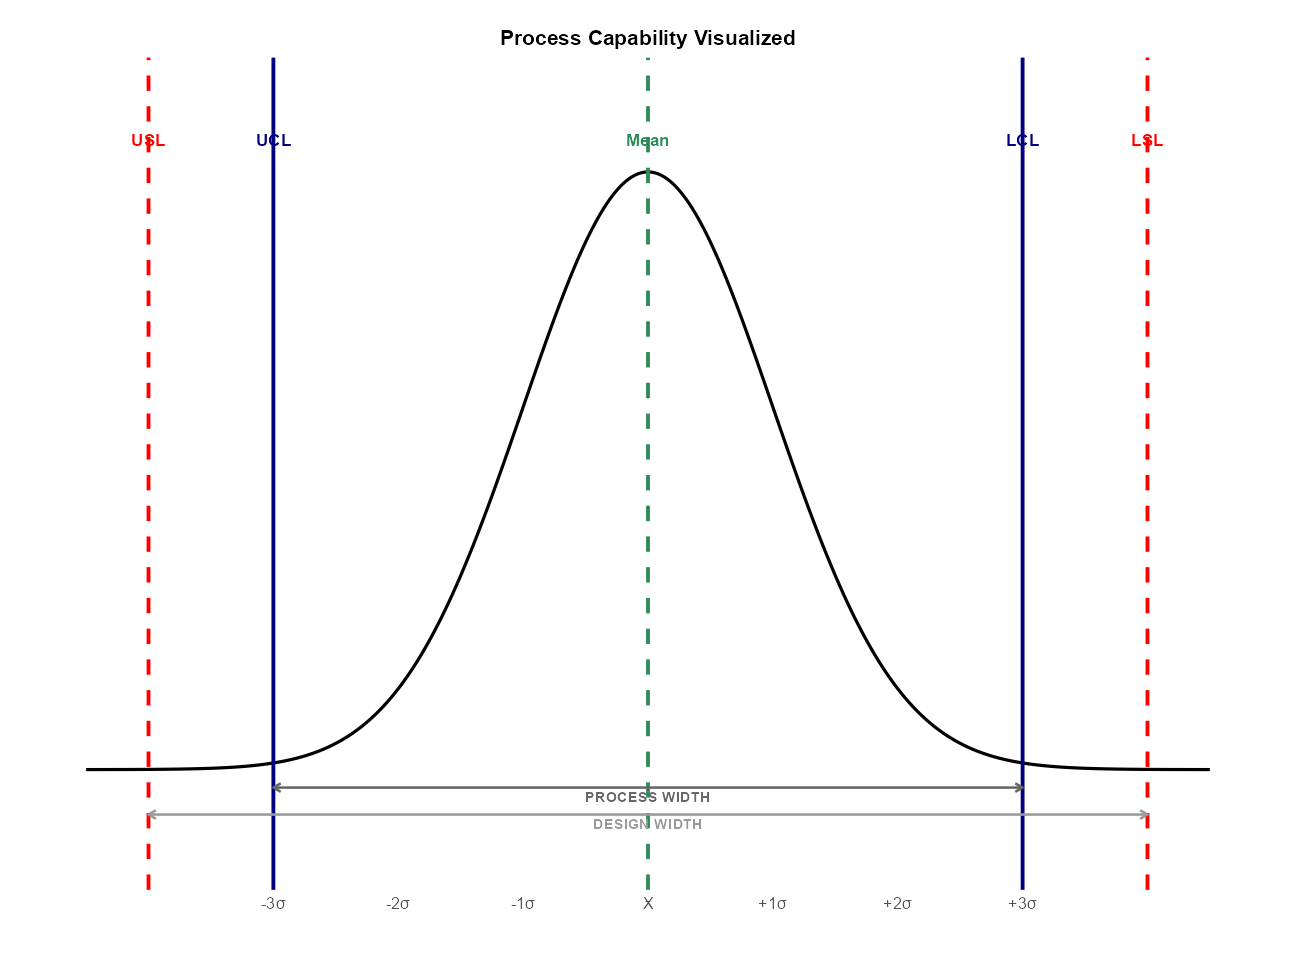

In [19]:
library(tidyverse)

# Parameters
mu <- 0
sigma <- 1
x <- seq(-4.5, 4.5, length.out = 1000)
y <- dnorm(x, mu, sigma)
df <- data.frame(x = x, y = y)

ggplot(df, aes(x, y)) +
  # Normal curve
  geom_line(linewidth = 1) +
  
  # UCL and LCL (Voice of the Process, ±3σ)
  geom_vline(xintercept = c(-3, 3), color = "navy", linewidth = 1.2) +
  
  # USL and LSL (Voice of the Customer, outside ±3σ)
  geom_vline(xintercept = c(-4, 4), color = "red", linewidth = 1.2,
             linetype = "dashed") +
  
  # Mean
  geom_vline(xintercept = 0, color = "#2e8b57", linewidth = 1.2,
             linetype = "dashed") +

  labs(title = "Process Capability Visualized") +
  
  # Sigma tick labels on x-axis
  scale_x_continuous(
    breaks = c(-3, -2, -1, 0, 1, 2, 3),
    labels = c("-3σ", "-2σ", "-1σ", "X̄", "+1σ", "+2σ", "+3σ")
  ) +
  
  # Process width arrow
  annotate("segment", x = -3, xend = 3, y = -0.012, yend = -0.012,
           arrow = arrow(ends = "both", length = unit(0.2, "cm")),
           color = "gray40", linewidth = 0.8) +
  annotate("text", x = 0, y = -0.018, label = "PROCESS WIDTH",
           size = 3.5, color = "gray40", fontface = "bold") +
  
  # Design width arrow
  annotate("segment", x = -4, xend = 4, y = -0.030, yend = -0.030,
           arrow = arrow(ends = "both", length = unit(0.2, "cm")),
           color = "gray60", linewidth = 0.8) +
  annotate("text", x = 0, y = -0.036, label = "DESIGN WIDTH",
           size = 3.5, color = "gray60", fontface = "bold") +
  
  # Line labels: UCL, LCL
  annotate("text", x = -3, y = 0.42, label = "UCL", color = "navy",
           fontface = "bold", size = 4) +
  annotate("text", x = 3, y = 0.42, label = "LCL", color = "navy",
           fontface = "bold", size = 4) +
  
  # Line labels: USL, LSL
  annotate("text", x = -4, y = 0.42, label = "USL", color = "red",
           fontface = "bold", size = 4) +
  annotate("text", x = 4, y = 0.42, label = "LSL", color = "red",
           fontface = "bold", size = 4) +
  
  # Mean label
  annotate("text", x = 0, y = 0.42, label = "Mean", color = "#2e8b57",
           fontface = "bold", size = 4) +
  
  # Theme cleanup
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 11),
    plot.margin = margin(t = 20, r = 20, b = 40, l = 20)
  ) +
  coord_cartesian(ylim = c(-0.055, 0.45), clip = "off")